# **1. Dataset**

## Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset Loading

In [ ]:
DATA_PATH = "data.csv"
df = pd.read_csv(DATA_PATH)

## Landmark Selection

In [ ]:
selected_columns = [
    "subject",
    "upperbody_label",
    "nose_x", "nose_y", "nose_z",
    "left_eye_x", "left_eye_y", "left_eye_z",
    "right_eye_x", "right_eye_y", "right_eye_z",
    "left_ear_x", "left_ear_y", "left_ear_z",
    "right_ear_x", "right_ear_y", "right_ear_z",
    "left_shoulder_x", "left_shoulder_y", "left_shoulder_z",
    "right_shoulder_x", "right_shoulder_y", "right_shoulder_z",
    "left_hip_x", "left_hip_y", "left_hip_z",
    "right_hip_x", "right_hip_y", "right_hip_z"
]

missing_cols = [col for col in selected_columns if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

df_posture = df[selected_columns].copy()

print("Selected dataset shape:", df_posture.shape)
print("Total missing values:", df_posture.isnull().sum().sum())

## Midpoint Construction

In [ ]:
# Thresholds for future consistency with the real-time pipeline
HEAD_Z_CONF_THR = 0.6
SHOULDER_CONF_THR = 0.6
HIP_CONF_THR = 0.6


# Compute the midpoint between two bilateral landmarks
def add_midpoint(df, left_prefix, right_prefix, out_prefix):
    # Check whether all coordinates are available for the left landmark
    left_available = df[
        [f"{left_prefix}_{axis}" for axis in ["x", "y", "z"]]
    ].notna().all(axis=1)

    # Check whether all coordinates are available for the right landmark
    right_available = df[
        [f"{right_prefix}_{axis}" for axis in ["x", "y", "z"]]
    ].notna().all(axis=1)

    # The midpoint is available only when both landmarks are present
    available = left_available & right_available

    # Compute midpoint coordinates for each axis
    for axis in ["x", "y", "z"]:
        midpoint = (df[f"{left_prefix}_{axis}"] + df[f"{right_prefix}_{axis}"]) / 2
        df[f"{out_prefix}_{axis}"] = np.where(available, midpoint, np.nan)

    # Store binary availability information
    df[f"{out_prefix}_available"] = available

    # Store binary confidence information
    # The offline dataset does not provide continuous visibility scores
    df[f"{out_prefix}_conf"] = available.astype(float)

    return df


# Compute bilateral midpoints used for posture representation
df_posture = add_midpoint(df_posture, "left_shoulder", "right_shoulder", "mid_shoulder")
df_posture = add_midpoint(df_posture, "left_hip", "right_hip", "mid_hip")
df_posture = add_midpoint(df_posture, "left_ear", "right_ear", "mid_ear")
df_posture = add_midpoint(df_posture, "left_eye", "right_eye", "mid_eye")


# Define reliability flags for the main structural midpoints
df_posture["mid_shoulder_reliable"] = df_posture["mid_shoulder_available"]
df_posture["mid_hip_reliable"] = df_posture["mid_hip_available"]


# Check availability of candidate landmarks for head center construction
eye_available = df_posture[
    [
        "left_eye_x", "left_eye_y", "left_eye_z",
        "right_eye_x", "right_eye_y", "right_eye_z"
    ]
].notna().all(axis=1)

ear_available = df_posture[
    [
        "left_ear_x", "left_ear_y", "left_ear_z",
        "right_ear_x", "right_ear_y", "right_ear_z"
    ]
].notna().all(axis=1)

nose_available = df_posture[
    ["nose_x", "nose_y", "nose_z"]
].notna().all(axis=1)


# Construct head center coordinates using a hierarchical fallback strategy
# Priority: mid-eye -> mid-ear -> nose
for axis in ["x", "y", "z"]:
    df_posture[f"head_center_{axis}"] = np.where(
        eye_available,
        df_posture[f"mid_eye_{axis}"],
        np.where(
            ear_available,
            df_posture[f"mid_ear_{axis}"],
            np.where(
                nose_available,
                df_posture[f"nose_{axis}"],
                np.nan
            )
        )
    )


# Track which landmark source was used for head center construction
df_posture["head_center_source"] = np.where(
    eye_available,
    "mid_eye",
    np.where(
        ear_available,
        "mid_ear",
        np.where(nose_available, "nose", "missing")
    )
)


# Store availability and binary confidence for head center
df_posture["head_center_available"] = (
    eye_available |
    ear_available |
    nose_available
)

# The offline dataset uses binary confidence only
df_posture["head_center_conf"] = df_posture["head_center_available"].astype(float)


# Define z-axis reliability flags
# Depth is considered more reliable when head center comes from bilateral landmarks
df_posture["head_center_z_reliable"] = df_posture["head_center_source"].isin(
    ["mid_eye", "mid_ear"]
)

# Upper-body depth is reliable only if both head center and shoulder midpoint are reliable
df_posture["upper_z_reliable"] = (
    df_posture["head_center_z_reliable"] &
    df_posture["mid_shoulder_reliable"]
)


# Quick inspection of the generated midpoint and reliability features
print(
    df_posture[
        [
            "mid_shoulder_x", "mid_shoulder_y", "mid_shoulder_z",
            "mid_shoulder_available", "mid_shoulder_conf", "mid_shoulder_reliable",

            "mid_hip_x", "mid_hip_y", "mid_hip_z",
            "mid_hip_available", "mid_hip_conf", "mid_hip_reliable",

            "mid_ear_x", "mid_ear_y", "mid_ear_z",
            "mid_ear_available", "mid_ear_conf",

            "mid_eye_x", "mid_eye_y", "mid_eye_z",
            "mid_eye_available", "mid_eye_conf",

            "head_center_x", "head_center_y", "head_center_z",
            "head_center_source", "head_center_available", "head_center_conf",

            "head_center_z_reliable",
            "upper_z_reliable"
        ]
    ].head()
)

## Feature Definition

### Primary Features

In [ ]:
eps = 1e-6

# Wrap angle to [-90, 90)
def wrap_angle_90(angle_deg):
    return ((angle_deg + 90) % 180) - 90


# Signed angular difference in [-180, 180)
def angle_diff_deg(a, b):
    return (a - b + 180) % 360 - 180


# Required columns check
required_columns = [
    "left_shoulder_x", "left_shoulder_y",
    "right_shoulder_x", "right_shoulder_y",
    "left_eye_x", "left_eye_y", "right_eye_x", "right_eye_y",
    "left_ear_x", "left_ear_y", "right_ear_x", "right_ear_y",
    "head_center_x", "head_center_y", "head_center_z",
    "mid_shoulder_x", "mid_shoulder_y", "mid_shoulder_z",
    "upper_z_reliable"
]

missing_columns = [col for col in required_columns if col not in df_posture.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")


# =========================
# 1) SHOULDERS GEOMETRY
# =========================
dx_shoulder = df_posture["right_shoulder_x"] - df_posture["left_shoulder_x"]
dy_shoulder = df_posture["right_shoulder_y"] - df_posture["left_shoulder_y"]

df_posture["shoulder_slope"] = wrap_angle_90(
    np.degrees(np.arctan2(dy_shoulder, dx_shoulder))
)

df_posture["shoulder_width"] = np.hypot(dx_shoulder, dy_shoulder)
df_posture["shoulder_width"] = df_posture["shoulder_width"].replace(0, np.nan)
df_posture["shoulder_width_safe"] = df_posture["shoulder_width"].fillna(eps)

u_x = dx_shoulder / df_posture["shoulder_width_safe"]
u_y = dy_shoulder / df_posture["shoulder_width_safe"]

n_x = -u_y
n_y = u_x

flip_mask = n_y > 0
n_x = np.where(flip_mask, -n_x, n_x)
n_y = np.where(flip_mask, -n_y, n_y)


# =========================
# 2) HEAD ORIENTATION
# =========================
eye_available = df_posture[
    ["left_eye_x", "left_eye_y", "right_eye_x", "right_eye_y"]
].notna().all(axis=1)

ear_available = df_posture[
    ["left_ear_x", "left_ear_y", "right_ear_x", "right_ear_y"]
].notna().all(axis=1)

dx_eye = df_posture["right_eye_x"] - df_posture["left_eye_x"]
dy_eye = df_posture["right_eye_y"] - df_posture["left_eye_y"]
head_tilt_eye = wrap_angle_90(np.degrees(np.arctan2(dy_eye, dx_eye)))

dx_ear = df_posture["right_ear_x"] - df_posture["left_ear_x"]
dy_ear = df_posture["right_ear_y"] - df_posture["left_ear_y"]
head_tilt_ear = wrap_angle_90(np.degrees(np.arctan2(dy_ear, dx_ear)))

df_posture["head_tilt"] = np.where(
    eye_available,
    head_tilt_eye,
    np.where(ear_available, head_tilt_ear, np.nan)
)


# =========================
# 3) HEAD RELATIVE TO SHOULDERS
# =========================
H_x = df_posture["head_center_x"] - df_posture["mid_shoulder_x"]
H_y = df_posture["head_center_y"] - df_posture["mid_shoulder_y"]
H_z = df_posture["head_center_z"] - df_posture["mid_shoulder_z"]

proj_shoulder_axis   = H_x * u_x + H_y * u_y
proj_shoulder_normal = H_x * n_x + H_y * n_y

df_posture["head_lateral_ratio"] = proj_shoulder_axis / df_posture["shoulder_width_safe"]
df_posture["head_y_ratio"]       = proj_shoulder_normal / df_posture["shoulder_width_safe"]


# =========================
# 4) 2D POSTURAL ANGLES
# =========================
df_posture["upper_body_inclination"] = wrap_angle_90(
    np.degrees(np.arctan2(proj_shoulder_axis, proj_shoulder_normal + eps))
)

norm_H_2d = np.sqrt(H_x**2 + H_y**2) + eps
cos_theta = (-H_y) / norm_H_2d
cos_theta = np.clip(cos_theta, -1.0, 1.0)

df_posture["head_neck_vertical_angle"] = np.degrees(np.arccos(cos_theta))


# =========================
# 5) RELATIVE ANGULAR FEATURES
# =========================
df_posture["head_shoulder_alignment"] = angle_diff_deg(
    df_posture["head_tilt"],
    df_posture["shoulder_slope"]
)

df_posture["head_trunk_diff"] = angle_diff_deg(
    df_posture["head_tilt"],
    df_posture["upper_body_inclination"]
)

# =========================
# 6) DIAGNOSTIC (non entra nel modello)
# =========================
df_posture["head_depth_ratio_diag"] = np.where(
    df_posture["upper_z_reliable"],
    H_z / df_posture["shoulder_width_safe"],
    np.nan
)


# =========================
# 7) FINAL PRIMARY FEATURE LIST — 8 feature
# =========================
primary_features = [
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
]

missing_primary_features = [col for col in primary_features if col not in df_posture.columns]
if missing_primary_features:
    raise KeyError(f"Missing primary features: {missing_primary_features}")

print("PRIMARY FEATURES:")
print(primary_features)

### Support Features

The support features extend the postural representation by incorporating additional information derived from the pelvis, whenever these landmarks are available and sufficiently reliable. These features do not constitute the core of the dataset; rather, they provide an additional level of postural description that is particularly useful for modeling trunk alignment.

More specifically, this group includes measures describing the geometry of the segment between the hips and the shoulders, such as trunk lateral inclination, forward/backward trunk inclination, and its depth-related component. In addition, an anatomical feature is introduced to approximate the relationship between the neck/head direction and the trunk direction.

Since these measures depend on the correct observation of the hip landmarks, they are computed only when the required anatomical references are available. In this way, the support features maintain a complementary role: they enrich the dataset when reliable information is present, without compromising the overall robustness of the pipeline.

In [ ]:
# =========================
# VETTORI
# =========================
T_x = df_posture["mid_shoulder_x"] - df_posture["mid_hip_x"]
T_y = df_posture["mid_shoulder_y"] - df_posture["mid_hip_y"]
T_z = df_posture["mid_shoulder_z"] - df_posture["mid_hip_z"]

# =========================
# RELIABILITY FLAG
# =========================
df_posture["trunk_support_reliable"] = (
    df_posture["mid_shoulder_reliable"] &
    df_posture["mid_hip_reliable"]
)

# =========================
# trunk_forward_backward_angle — FIX: -T_y
# =========================
# arctan2(T_z, -T_y):
#   T_z > 0 → testa più vicina alla camera delle anche → forward lean → angolo positivo
#   T_z < 0 → testa più lontana → backward lean → angolo negativo
#   -T_y > 0 sempre (spalle sopra anche) → angolo ~0° in postura neutra

trunk_fba_raw = np.degrees(
    np.arctan2(T_z, -T_y + 1e-6)
)

df_posture["trunk_forward_backward_angle"] = np.where(
    df_posture["trunk_support_reliable"],
    trunk_fba_raw,
    np.nan
)

# =========================
# FINAL SUPPORT FEATURE LIST — 1 feature
# =========================
support_features = ["trunk_forward_backward_angle"]

missing_support = [col for col in support_features if col not in df_posture.columns]
if missing_support:
    raise KeyError(f"Missing support features: {missing_support}")

print("SUPPORT FEATURES (fixate):")
print(support_features)

print("\nQuick check trunk_forward_backward_angle:")
print(df_posture["trunk_forward_backward_angle"].describe().round(3))
print(f"\nValori NaN: {df_posture['trunk_forward_backward_angle'].isna().sum()}")
print(f"Valori fuori [-30, 30]: {((df_posture['trunk_forward_backward_angle'].abs() > 30) & df_posture['trunk_forward_backward_angle'].notna()).sum()}")

## Final Dataset Construction

At this stage, the final dataset containing the features derived from the selected and transformed landmarks is assembled.

The features used by the model are obtained by combining the **primary features**, based on head and shoulder information, with the **support features**, derived from trunk-related geometry when the required landmarks are available. This integration makes it possible to preserve a balance between robustness and completeness in the postural representation.

During the previous stages, several intermediate variables are also generated, including vector components, normalized quantities, and diagnostic features. These variables are retained in the working DataFrame to ensure traceability and to facilitate debugging. However, they are not included in the final model dataset, in order to avoid redundancy and to preserve a compact and interpretable feature representation.

Two distinct datasets are generated:

- **Model dataset**: contains only the features used as model input, together with the subject identifier and the postural class label. This dataset represents the main output of the feature engineering pipeline.

- **Debug dataset**: includes, in addition to the model features, diagnostic variables and reliability flags. This version is intended to support transformation verification, feature inspection, and possible downstream error analysis.

Both datasets are saved in `.csv` format so that they can be reused in the subsequent stages of the project.

Finally, a set of basic structural checks is performed, including verification of dataset dimensionality, number of extracted features, and the overall amount of missing values. These checks ensure the correctness of the dataset construction process without entering the exploratory analysis stage, which will be addressed separately.

In [ ]:
# =========================
# FINAL FEATURE LIST — 8 primary + 1 support fixata
# =========================

all_feature_columns = primary_features + support_features

diagnostic_columns = [
    "shoulder_width",
    "shoulder_width_safe",
    "head_depth_ratio_diag",
]

id_columns = ["subject", "upperbody_label"]

control_columns = [
    "head_center_source",
    "head_center_z_reliable",
    "upper_z_reliable",
    "mid_shoulder_reliable",
    "trunk_support_reliable",
]

required_columns = (
    id_columns
    + all_feature_columns
    + diagnostic_columns
    + control_columns
)

missing_columns = [col for col in required_columns if col not in df_posture.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

# =========================
# FINAL MODEL DATASET
# =========================
df_features = df_posture[id_columns + all_feature_columns].copy()

df_features_debug = df_posture[
    id_columns + all_feature_columns + diagnostic_columns + control_columns
].copy()

if df_features.empty:
    raise ValueError("The final feature dataset is empty.")

print("Model dataset missing values:")
print(df_features.isnull().sum().sort_values(ascending=False))

print("\nDatasets saved.")
print("Model dataset shape:", df_features.shape)
print("Feature columns:", all_feature_columns)

df_features.to_csv("posture_features.csv", index=False)
df_features_debug.to_csv("posture_features_debug.csv", index=False)

# 1. Dataset Analysis

## 1.1 Initial Dataset
The raw dataset consists of pose landmark coordinates extracted via MediaPipe Pose from video recordings of **3 subjects** performing upper-body postural variations. Each row corresponds to a single frame and contains the 3D coordinates (x, y, z) of the 33 MediaPipe body landmarks, along with a subject identifier and a postural label.

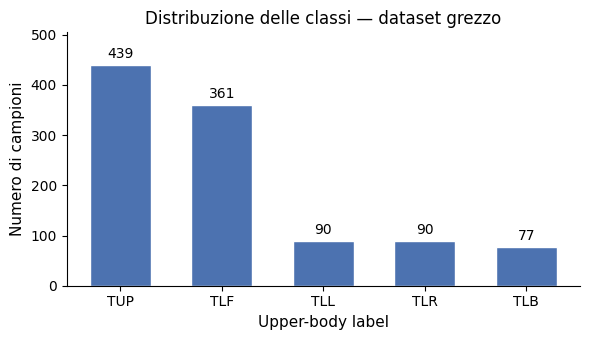

upperbody_label  TUP  TLF  TLL  TLR  TLB
subject                                 
1                203  163   60   60   54
2                236  142   30   30   12
3                  0   56    0    0   11

Totale NaN: 49
Righe coinvolte: 1
Colonne coinvolte: 49


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("report_figures", exist_ok=True)

DATA_PATH = "data.csv"
df_raw = pd.read_csv(DATA_PATH)

# --- Plot: distribuzione classi ---
label_counts = df_raw['upperbody_label'].value_counts()
label_order  = label_counts.index.tolist()

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(label_order, label_counts.values, color="#4C72B0", edgecolor="white", width=0.6)
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            str(val), ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Upper-body label", fontsize=11)
ax.set_ylabel("Numero di campioni", fontsize=11)
ax.set_title("Distribuzione delle classi — dataset grezzo", fontsize=12)
ax.set_ylim(0, label_counts.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("report_figures/fig1_class_distribution.png", dpi=150)
plt.show()

# --- Stampa tabella soggetti x classe ---
subj_label = (df_raw
              .groupby(["subject", "upperbody_label"])
              .size()
              .unstack(fill_value=0)
              [label_order])
print(subj_label.to_string())

# --- Stampa missing values ---
landmark_cols = [c for c in df_raw.columns
                 if c not in ["subject", "upperbody_label", "lowerbody_label"]]
missing = df_raw[landmark_cols].isnull().sum()
print(f"\nTotale NaN: {missing.sum()}")
print(f"Righe coinvolte: {df_raw[landmark_cols].isnull().any(axis=1).sum()}")
print(f"Colonne coinvolte: {(missing > 0).sum()}")